In [88]:
from dotenv import load_dotenv
load_dotenv()

True

In [89]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [90]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [91]:
class MailState(BaseModel):
    query:str = ""
    draft:str = ""
    human_feedback:str = ""
    final_response:str = ""

In [92]:
#### Defining the node

def draft_email(state:MailState) -> MailState:

    if state.human_feedback:
        draft = llm.invoke(f"""
                            Rewrite this draft mail for {state.query}, You have generated  this mail: {state.draft}, Human Feedback to apply: {state.human_feedback},     
                            """).content
    else:
        draft = llm.invoke(state.query).content
    state.draft = draft
    return state

In [93]:
def human_feedback(state:MailState)->MailState:
    feedback = interrupt({
        "draft_email":state.draft,
        "question": "Do you want to continue or re-write the mail?"
    })

    fb = (feedback or "").strip().lower()
    if fb in ["approved", "ok", "fine", "yes"]:
        state.human_feedback = ""
        return state
    else:
        state.human_feedback = feedback
        return state


In [94]:
def finalize_node(state:MailState)->MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print("Email Send Succefully...")
        state.final_response = "Mail send successfully"
        return state


In [95]:
def conditional_node(state:MailState)->Literal["draft", "finalize"]:
    if state.human_feedback:
        return "draft"
    return "finalize"

#### Create graph

In [96]:
graph = StateGraph(MailState)

# node

graph.add_node("draft", draft_email)
graph.add_node("feedback", human_feedback)
graph.add_node("finalize", finalize_node)

graph.add_edge(START, "draft")
graph.add_edge("draft", "feedback")
graph.add_conditional_edges("feedback", conditional_node)
graph.add_edge("finalize",END)

graph = graph.compile(checkpointer=InMemorySaver())

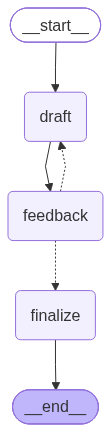

In [97]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [98]:
config = {"configurable":{"thread_id": 1}}

In [99]:
res = graph.invoke({"query":"I want to send a email to my HR as im am resigning senior associate 1, So create a simple mail"}, config=config)

In [100]:
res

{'query': 'I want to send a email to my HR as im am resigning senior associate 1, So create a simple mail',
 'draft': '**Subject:** Resignation – Senior Associate 1 (Notice Period)\n\nDear [HR Manager’s Name],\n\nI am writing to formally resign from my position as Senior Associate 1 at [Company Name], effective **[last working day, e.g., 30\u202fSeptember\u202f2026]** in accordance with the company’s notice period of [X] weeks/months.\n\nI would like to express my sincere gratitude for the opportunities, support, and experiences I have gained during my tenure. Working with such a talented team has been both rewarding and inspiring.\n\nPlease let me know the next steps for a smooth transition, including any hand‑over procedures or documentation you require. I am committed to ensuring all my responsibilities are wrapped up before my departure.\n\nThank you again for everything. I look forward to staying in touch and wish the team continued success.\n\nBest regards,\n\n[Your Full Name]  \

In [103]:
res = graph.invoke(Command(resume="now replace with my name and my name is Vineet Sharma"),config=config)
print(res["draft"])


**Subject:** Resignation Notice – Vineet Sharma  

Dear [HR Manager’s Name],

I am writing to formally resign from my position as Senior Associate 1 at [Company Name], effective **[last working day, e.g., 30 September 2026]** in accordance with the company’s notice period.

I appreciate the opportunities and support I have received during my time here. I am committed to making the transition as smooth as possible and would be grateful for guidance on hand‑over procedures or any documentation you need from me.

Thank you again for everything. I look forward to staying in touch and wish the team continued success.

Best regards,

**Vineet Sharma**  
[Your Phone Number] | [Your Email]


In [104]:
res = graph.invoke(Command(resume="ok"),config=config)
print(res)


Email Send Succefully...
{'query': 'I want to send a email to my HR as im am resigning senior associate 1, So create a simple mail', 'draft': '**Subject:** Resignation Notice – Vineet Sharma  \n\nDear [HR Manager’s Name],\n\nI am writing to formally resign from my position as Senior Associate\u202f1 at [Company Name], effective **[last working day, e.g., 30\u202fSeptember\u202f2026]** in accordance with the company’s notice period.\n\nI appreciate the opportunities and support I have received during my time here. I am committed to making the transition as smooth as possible and would be grateful for guidance on hand‑over procedures or any documentation you need from me.\n\nThank you again for everything. I look forward to staying in touch and wish the team continued success.\n\nBest regards,\n\n**Vineet Sharma**  \n[Your Phone Number] | [Your Email]', 'human_feedback': '', 'final_response': 'Mail send successfully'}
